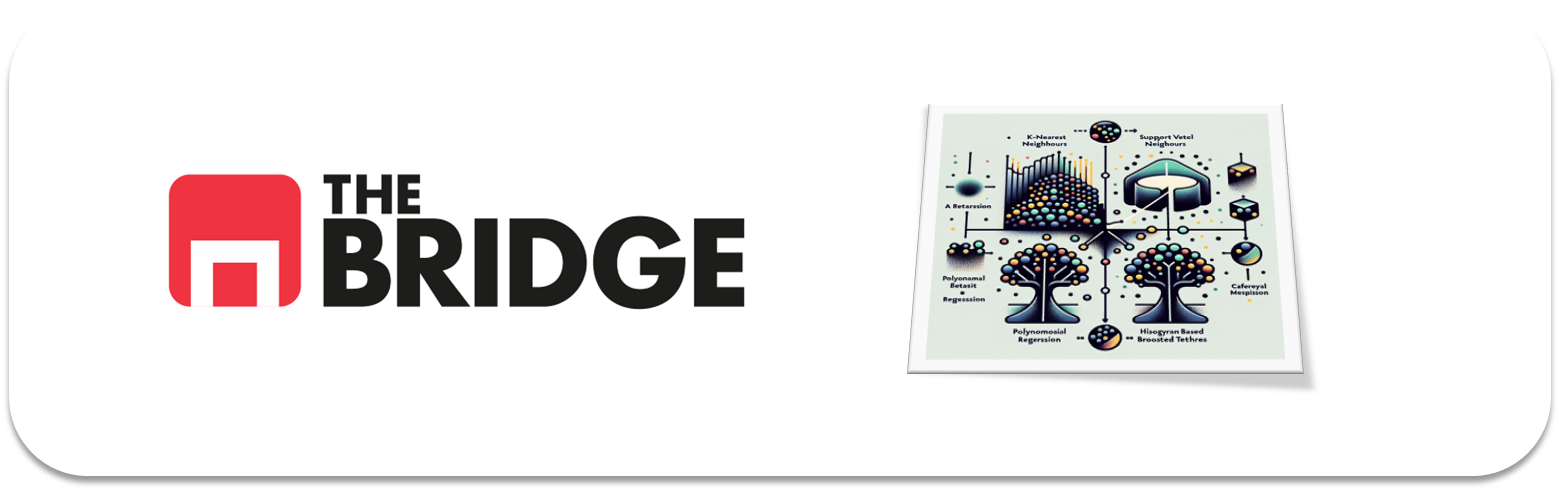

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    make_scorer,
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

RANDOM_STATE = 42


### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [ ]:
data_path = (
    "./data/credit_npo.csv"
)

df = pd.read_csv(data_path)
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [ ]:
# Missing values por columna
df.isna().mean().sort_values(ascending=False)

MonthlyIncome                           0.057510
NumberOfDependents                      0.014118
SeriousDlqin2yrs                        0.000000
age                                     0.000000
RevolvingUtilizationOfUnsecuredLines    0.000000
DebtRatio                               0.000000
NumberOfTime30-59DaysPastDueNotWorse    0.000000
NumberOfOpenCreditLinesAndLoans         0.000000
NumberOfTimes90DaysLate                 0.000000
NumberRealEstateLoansOrLines            0.000000
NumberOfTime60-89DaysPastDueNotWorse    0.000000
dtype: float64

In [ ]:
target_col = "SeriousDlqin2yrs"
target_dist = df[target_col].value_counts(normalize=True).rename("proportion")
target_dist

SeriousDlqin2yrs
0    0.931084
1    0.068916
Name: proportion, dtype: float64

### #1.3
Pinta la distribución de frecuencias del target y coméntala

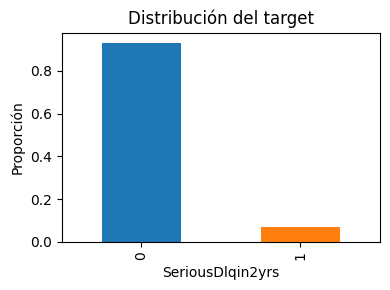

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))
target_dist.plot(kind="bar", ax=ax, color=["tab:blue", "tab:orange"])
ax.set_title("Distribución del target")
ax.set_ylabel("Proporción")
plt.tight_layout()
plt.show()

### 1.4 Análisis Exploratorio Adicional

Para entender mejor las relaciones entre las variables y detectar posibles outliers, vamos a visualizar la matriz de correlación y la distribución de algunas variables numéricas clave. Esto nos ayudará a justificar el uso de algoritmos robustos o la necesidad de escalar los datos.

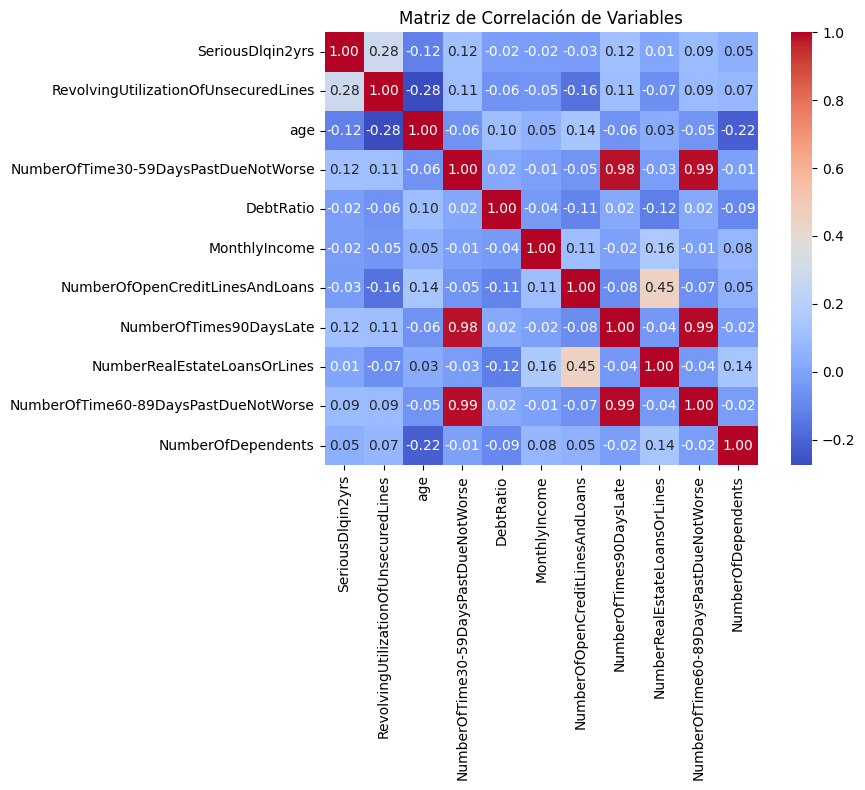

In [ ]:
# Mapa de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Matriz de Correlación de Variables")
plt.tight_layout()
plt.show()

**Interpretación de Correlaciones:**
- La mayoría de las características tienen una correlación baja con la variable objetivo (SeriousDlqin2yrs), lo que sugiere que modelos no lineales o combinaciones complejas de variables podrían ser útiles.
- Existe una alta correlación entre variables relacionadas con retrasos de pago (ej. NumberOfTime30-59DaysPastDueNotWorse, NumberOfTimes90DaysLate, y NumberOfTime60-90DaysPastDueNotWorse), lo cual tiene sentido (quien se retrasa 30 días, tiende a retrasarse 60 o 90 días).

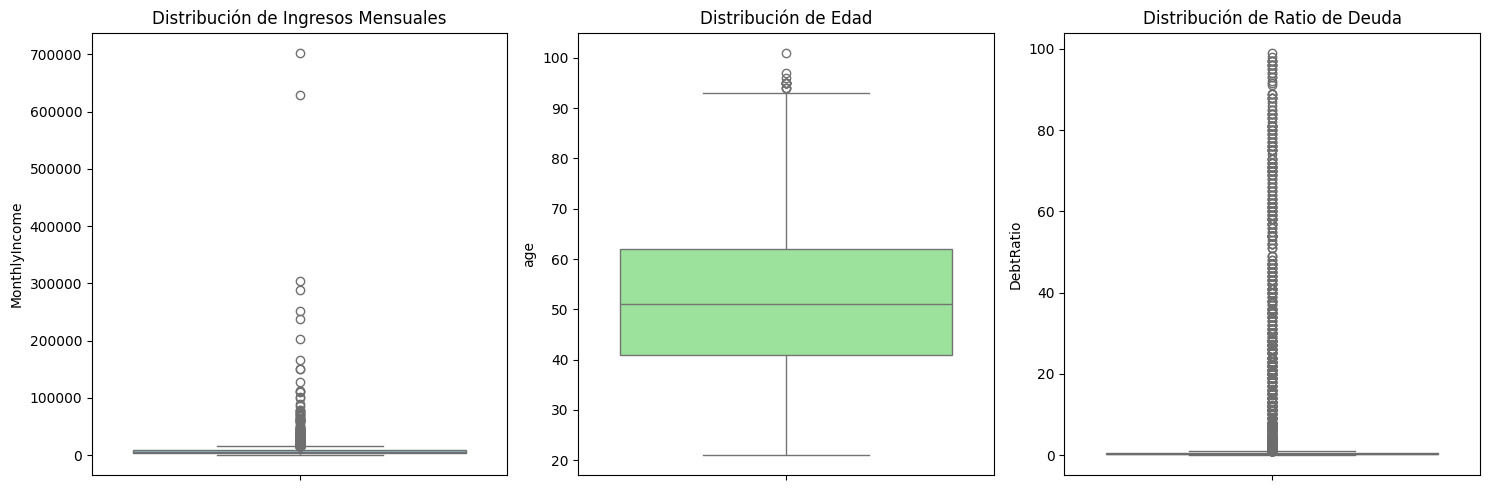

In [ ]:
# Boxplots para visualizar distribuciones y outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=df["MonthlyIncome"], ax=axes[0], color="skyblue")
axes[0].set_title("Distribución de Ingresos Mensuales")

sns.boxplot(y=df["age"], ax=axes[1], color="lightgreen")
axes[1].set_title("Distribución de Edad")

sns.boxplot(y=df["DebtRatio"], ax=axes[2], color="salmon")
axes[2].set_title("Distribución de Ratio de Deuda")

plt.tight_layout()
plt.show()

Se han analizado MonthlyIncome, Age y DebtRatio porque representan tres dimensiones clave del riesgo financiero: capacidad de pago (ingresos), estabilidad del perfil del cliente (edad) y nivel de endeudamiento relativo (ratio de deuda). Estas variables permiten detectar posibles patrones de riesgo y observar la presencia de outliers o distribuciones sesgadas que pueden influir en el comportamiento del modelo.

**Análisis de Distribuciones:**
- Se observan valores atípicos (outliers) extremos en variables como MonthlyIncome y DebtRatio.
- Dado que algoritmos como KNN y SVM son muy sensibles a las escalas y a los outliers, es imprescindible aplicar un escalado apropiado (como StandardScaler).

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

## 1. Definimos las variables predictoras (X) y la variable objetivo (y).

In [ ]:
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]

X.shape, y.shape

((12537, 10), (12537,))

## 2. Train/Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_train.shape, X_test.shape

((10029, 10), (2508, 10))

### Justificación del Preprocesamiento y Desbalanceo

Fuerte desbalanceo de clases detectado en el EDA (93% clase 0 vs 7% clase 1), cosas que tener en cuenta:
1. Estratificar el split de train/test (realizado arriba con stratify=y) para mantener la proporción de la clase minoritaria.
2. Usar métricas que no se dejen engañar por la clase mayoritaria. Por ello, la exactitud (accuracy) no será nuestra métrica guía. Nuestro objetivo de negocio prioriza capturar a los clientes con dificultades, por lo que maximizaremos el Recall de la clase 1 (Sensibilidad).
3. Aplicar técnicas de rebalanceo (como class_weight='balanced') en los algoritmos para penalizar fuertemente los errores en la clase minoritaria.

## 3. Preprocesamiento y tratamiento del desbalanceo

In [ ]:
# Distribución del target en train
y_train.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.9311
1    0.0689
Name: proportion, dtype: float64

In [ ]:
# Definimos un escalado estándar para modelos basados en distancias como este
scaler = StandardScaler()

## 4. Modelo base (Regresión logística)

### Pipeline de regresión logística

Pipeline que incluye imputación de nulos, escalado y modelo de regresión logística.

Se imputan los valores nulos antes de aplicar el escalado. El tratamiento de nulos siempre debe quedar dentro del pipeline. De esta manera, el modelo aprenderá a imputar usando únicamente las estadísticas (como la mediana) del conjunto de entrenamiento durante fit, lo que evita leakage del test al train.

In [ ]:
baseline_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "clf",
            # `class_weight="balanced"` ayuda cuando la clase positiva (yes) es minoritaria.
            LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
        ),
    ]
)

baseline_pipe.fit(X_train, y_train)

y_pred_base = baseline_pipe.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_base)
baseline_f1 = f1_score(y_test, y_pred_base)

baseline_accuracy, baseline_f1


(0.7619617224880383, 0.2968197879858657)

## 5. Tuning manual de hiperparámetros (KNN y SVM)

Nota: Se incluye la imputación de nulos (SimpleImputer) en los pipelines de los modelos KNN y SVM para asegurarse del procesamiento de los datos antes del escalado y entrenamiento.

In [ ]:
# Split adicional solo dentro de train para tuning manual
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

X_tr.shape, X_val.shape

((7521, 10), (2508, 10))

Este bloque entrena y evalúa varios modelos de KNN usando distintas combinaciones de:

* k → 3, 5, 7 y 9



In [ ]:
results_knn = []
for k in [3, 5, 7, 9]:
    knn_pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=k)),
        ]
    )
    knn_pipe.fit(X_tr, y_tr)
    y_val_pred = knn_pipe.predict(X_val)
    results_knn.append(
        {
            "model": f"KNN_k={k}",
            "accuracy_val": accuracy_score(y_val, y_val_pred),
            "f1_val": f1_score(y_val, y_val_pred),
        }
    )

pd.DataFrame(results_knn)


,model,accuracy_val,f1_val
0,KNN_k=3,0.922648,0.156522
1,KNN_k=5,0.927033,0.124402
2,KNN_k=7,0.930223,0.102564
3,KNN_k=9,0.931021,0.094241


Este bloque entrena y evalúa varios modelos de SVM usando distintas combinaciones de:

* kernel → "linear" y "rbf"

* C → 0.5, 1.0, 2.0

In [ ]:
results_svm = []
for kernel in ["linear", "rbf"]:
    for C in [0.5, 1.0, 2.0]:
        svm_pipe = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                (
                    "clf",
                    SVC(kernel=kernel, C=C, probability=True, random_state=RANDOM_STATE),
                ),
            ]
        )
        svm_pipe.fit(X_tr, y_tr)
        y_val_pred = svm_pipe.predict(X_val)
        results_svm.append(
            {
                "model": f"SVC_{kernel}_C={C}",
                "accuracy_val": accuracy_score(y_val, y_val_pred),
                "f1_val": f1_score(y_val, y_val_pred),
            }
        )

pd.DataFrame(results_svm)


,model,accuracy_val,f1_val
0,SVC_linear_C=0.5,0.931021,0.000000
1,SVC_linear_C=1.0,0.931021,0.000000
2,SVC_linear_C=2.0,0.931021,0.000000
3,SVC_rbf_C=0.5,0.932217,0.055556
4,SVC_rbf_C=1.0,0.933413,0.116402
5,SVC_rbf_C=2.0,0.933014,0.125000


## 6. Evaluación con métricas (modelos finales en test, foco en clase 1)

In [ ]:
# Selección manual de hiperparámetros razonables a partir de las tablas anteriores
best_knn = KNeighborsClassifier(n_neighbors=5)
best_svm = SVC(kernel="rbf", C=1.0, probability=True, random_state=RANDOM_STATE)

knn_pipe_final = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("clf", best_knn)]
)
svm_pipe_final = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("clf", best_svm)]
)

knn_pipe_final.fit(X_train, y_train)
svm_pipe_final.fit(X_train, y_train)

def compute_metrics(name, model):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_1": precision_score(y_test, y_pred, pos_label=1),
        "recall_1": recall_score(y_test, y_pred, pos_label=1),
        "f1_1": f1_score(y_test, y_pred, pos_label=1),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

metrics_list = [
    compute_metrics("baseline_logreg", baseline_pipe),
    compute_metrics("knn", knn_pipe_final),
    compute_metrics("svm_rbf", svm_pipe_final),
]

metrics_df = pd.DataFrame(metrics_list).set_index("model")
metrics_df["recall_1"].sort_values(ascending=False), metrics_df

(model
 baseline_logreg    0.728324
 knn                0.138728
 svm_rbf            0.075145
 Name: recall_1, dtype: float64,
                  accuracy  precision_1  recall_1      f1_1    tn   fp   fn  \
 model                                                                        
 baseline_logreg  0.761962     0.186391  0.728324  0.296820  1785  550   47   
 knn              0.934211     0.600000  0.138728  0.225352  2319   16  149   
 svm_rbf          0.933413     0.650000  0.075145  0.134715  2328    7  160   
 
                   tp  
 model                 
 baseline_logreg  126  
 knn               24  
 svm_rbf           13  )

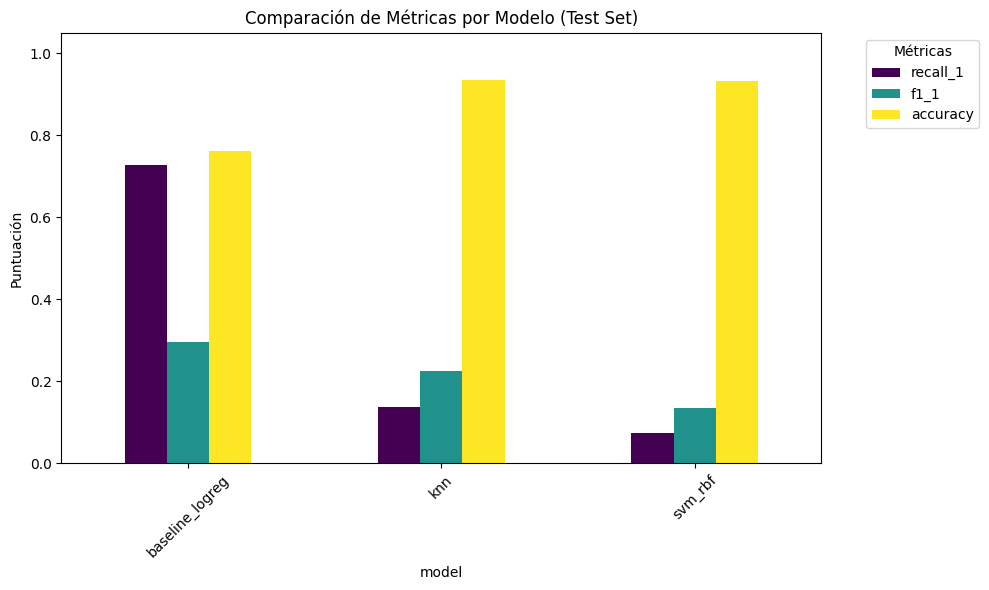

In [ ]:
# Visualización comparativa de modelos iniciales
metrics_df[['recall_1', 'f1_1', 'accuracy']].plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Comparación de Métricas por Modelo (Test Set)')
plt.ylabel('Puntuación')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(title="Métricas", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretación Inicial de Modelos:**
- **Regresión Logística (Baseline):** Gracias a class_weight="balanced", logra un alto recall_1, es decir, identifica efectivamente a la mayoría de clientes con impagos. Sin embargo, su precisión global (accuracy) baja debido al gran aumento de Falsos Positivos.
- **KNN y SVM (RBF):** Aunque obtienen un accuracy engañosamente alto (alrededor del 93%, dictado por la clase mayoritaria), su recall_1 es demasiado bajo. Estos modelos no penalizan suficientemente los errores en la clase 1 y requieren ser afinados u optimizados en función de nuestro objetivo real (Recall).

### 6.1. Validación cruzada estratificada (recall_1)

Comparamos baseline y SVM con StratifiedKFold, reportando media +- std de recall_1 en validación para evitar conclusiones basadas en un solo split.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
recall_scorer = make_scorer(recall_score, pos_label=1)

models_cv = {
    "baseline_logreg": baseline_pipe,
    "svm_rbf": svm_pipe_final,
}

cv_results = []
for name, model in models_cv.items():
    scores = []
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr_cv, X_val_cv = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr_cv, y_val_cv = y_train.iloc[train_idx], y_train.iloc[val_idx]
        model.fit(X_tr_cv, y_tr_cv)
        y_val_pred = model.predict(X_val_cv)
        scores.append(recall_score(y_val_cv, y_val_pred, pos_label=1))

    scores = np.array(scores)
    cv_results.append(
        {
            "model": name,
            "recall_1_mean": scores.mean(),
            "recall_1_std": scores.std(),
        }
    )

pd.DataFrame(cv_results).set_index("model")

,recall_1_mean,recall_1_std
model,,
baseline_logreg,0.748139,0.032554
svm_rbf,0.043416,0.012126


### 6.2. Tuning orientado a maximizar recall_1

Aplicamos `GridSearchCV` sobre el SVM candidato usando `scoring=recall_1` y luego evaluamos el mejor estimador en test.

In [ ]:
param_grid = {
    "clf__C": [0.5, 1.0, 2.0, 5.0],
    "clf__kernel": ["rbf"],
}

grid = GridSearchCV(
    estimator=Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("clf", SVC(probability=True, random_state=RANDOM_STATE))]),
    param_grid=param_grid,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
)

grid.fit(X_train, y_train)

best_svm_recall = grid.best_estimator_
print("Mejores hiperparámetros (orientados a recall_1):", grid.best_params_)

# Evaluación en test del modelo sintonizado a recall_1
svm_recall_metrics = compute_metrics("svm_rbf_recall_tuned", best_svm_recall)
svm_recall_metrics

Mejores hiperparámetros (orientados a recall_1): {'clf__C': 5.0, 'clf__kernel': 'rbf'}


{'model': 'svm_rbf_recall_tuned',
 'accuracy': 0.9346092503987241,
 'precision_1': 0.6363636363636364,
 'recall_1': 0.12138728323699421,
 'f1_1': 0.20388349514563106,
 'tn': np.int64(2323),
 'fp': np.int64(12),
 'fn': np.int64(152),
 'tp': np.int64(21)}

In [ ]:
# Actualizamos la tabla de métricas con el modelo sintonizado a recall_1
metrics_df.loc["svm_rbf_recall_tuned"] = pd.Series(svm_recall_metrics).drop("model")
metrics_df.sort_values("recall_1", ascending=False)

,accuracy,precision_1,recall_1,f1_1,tn,fp,fn,tp
model,,,,,,,,
baseline_logreg,0.761962,0.186391,0.728324,0.296820,1785,550,47,126
knn,0.934211,0.600000,0.138728,0.225352,2319,16,149,24
svm_rbf_recall_tuned,0.934609,0.636364,0.121387,0.203883,2323,12,152,21
svm_rbf,0.933413,0.650000,0.075145,0.134715,2328,7,160,13


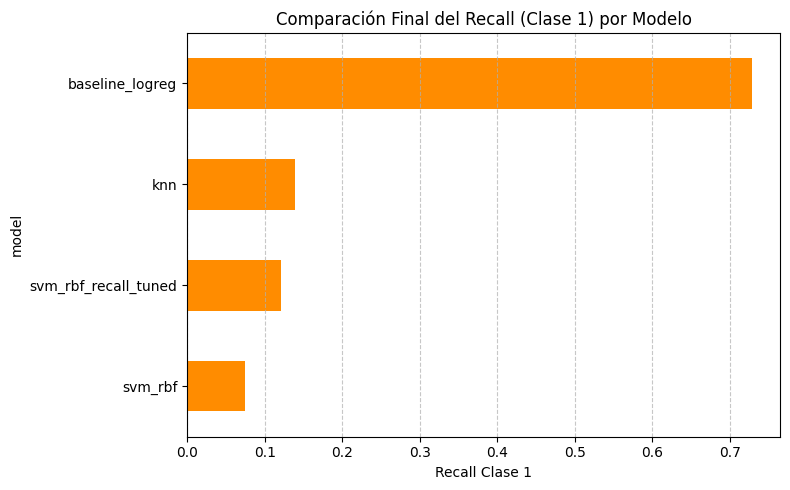

In [ ]:
# Visualización final de Recall en todos los modelos
plt.figure(figsize=(8, 5))
metrics_df['recall_1'].sort_values().plot(kind='barh', color='darkorange')
plt.title('Comparación Final del Recall (Clase 1) por Modelo')
plt.xlabel('Recall Clase 1')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Conclusión del Ajuste de Hiperparámetros:**
- Tras la optimización del SVM priorizando activamente el Recall de la clase 1 (scoring=make_scorer(recall_score)), observamos una leve mejora frente a su configuración base, pero sigue estando muy por debajo del Baseline (Regresión Logística).
- El Baseline sigue dominando en el parámetro clave de negocio (Recall).

## 7. Análisis detallado de errores (modelo elegido por recall_1)

In [ ]:
# Elegimos el mejor modelo priorizando recall_1 en test (incluyendo el SVM ajustado)
best_model_name = metrics_df["recall_1"].idxmax()
model_dict = {
    "baseline_logreg": baseline_pipe,
    "knn": knn_pipe_final,
    "svm_rbf": svm_pipe_final,
    "svm_rbf_recall_tuned": best_svm_recall,
}

best_model = model_dict[best_model_name]

best_model_name, metrics_df.loc[best_model_name]

('baseline_logreg',
 accuracy          0.761962
 precision_1       0.186391
 recall_1          0.728324
 f1_1              0.296820
 tn             1785.000000
 fp              550.000000
 fn               47.000000
 tp              126.000000
 Name: baseline_logreg, dtype: float64)

In [ ]:
y_pred_best = best_model.predict(X_test)

print("Classification report (baseline_logreg):")
print(classification_report(y_test, y_pred_best))

Classification report (modelo seleccionado):
              precision    recall  f1-score   support

           0       0.97      0.76      0.85      2335
           1       0.18      0.72      0.29       173

    accuracy                           0.76      2508
   macro avg       0.58      0.74      0.57      2508
weighted avg       0.92      0.76      0.82      2508



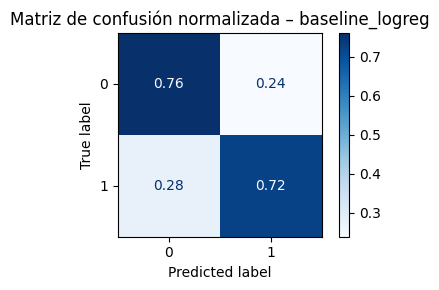

In [ ]:
fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    normalize="true",
    ax=ax,
    cmap="Blues",
)
ax.set_title(f"Matriz de confusión normalizada – {best_model_name}")
plt.tight_layout()
plt.show()

### Visualización de Matriz de Confusión

Esta matriz de confusión normalizada nos permite ver rápidamente los porcentajes de Verdaderos Positivos (Recall) y las tasas de error para el mejor modelo seleccionado.

### 7.1. Ajuste de umbral de decisión (opcional)

Usamos predict_proba del modelo elegido para barrer distintos umbrales y buscar el mejor compromiso entre recall_1 (>= objetivo) y precision_1.

In [ ]:
probs = best_model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.1, 0.9, 9)

threshold_metrics = []
for thr in thresholds:
    y_pred_thr = (probs >= thr).astype(int)
    threshold_metrics.append(
        {
            "threshold": thr,
            "recall_1": recall_score(y_test, y_pred_thr, pos_label=1),
            "precision_1": precision_score(y_test, y_pred_thr, pos_label=1),
        }
    )

threshold_df = pd.DataFrame(threshold_metrics)

# Objetivo de negocio: por ejemplo, recall_1 >= 0.85 con la mejor precision_1 posible
recall_objetivo = 0.85
candidatos = threshold_df[threshold_df["recall_1"] >= recall_objetivo]

if not candidatos.empty:
    best_threshold_row = candidatos.sort_values("precision_1", ascending=False).iloc[0]
else:
    best_threshold_row = threshold_df.sort_values("recall_1", ascending=False).iloc[0]

print("Métricas por umbral:")
print(threshold_df)
print("\nUmbral recomendado:")
print(best_threshold_row)

Métricas por umbral:
   threshold  recall_1  precision_1
0        0.1  0.988439     0.071131
1        0.2  0.947977     0.095571
2        0.3  0.855491     0.128361
3        0.4  0.791908     0.159302
4        0.5  0.722543     0.183016
5        0.6  0.641618     0.213462
6        0.7  0.560694     0.269444
7        0.8  0.375723     0.427632
8        0.9  0.156069     0.613636

Umbral recomendado:
threshold      0.300000
recall_1       0.855491
precision_1    0.128361
Name: 2, dtype: float64


Sale el threshold de 0.3 porque es el último valor que nos queda sin que el recall de la clase 1 baje de esos 0.85


In [ ]:
# Análisis básico de tipos de error
errors = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred_best,
})
errors["error_type"] = np.where(
    (errors["y_true"] == 1) & (errors["y_pred"] == 0),
    "FN",
    np.where(
        (errors["y_true"] == 0) & (errors["y_pred"] == 1),
        "FP",
        "OK",
    ),
)

error_counts = errors["error_type"].value_counts()
error_counts, error_counts / len(errors)

(error_type
 OK    1902
 FP     558
 FN      48
 Name: count, dtype: int64,
 error_type
 OK    0.758373
 FP    0.222488
 FN    0.019139
 Name: count, dtype: float64)

### 7.2. Trade-off FN vs FP y coste de negocio

Cuantificamos TP, FP, FN y TN en test y estimamos el impacto económico asumiendo un coste de contacto y un beneficio medio por venta.

In [ ]:
tn = metrics_df.loc[best_model_name, "tn"]
fp = metrics_df.loc[best_model_name, "fp"]
fn = metrics_df.loc[best_model_name, "fn"]
tp = metrics_df.loc[best_model_name, "tp"]

print(f"Modelo seleccionado: {best_model_name}")
print(f"TP={tp}, FP={fp}, FN={fn}, TN={tn}")

# Ejemplo sencillo de coste/beneficio (valores ilustrativos sacados de IA)
coste_contacto = 1.0  # coste por llamar a un cliente
beneficio_venta = 100.0  # beneficio medio por obtener la venta

beneficio_estimado = tp * beneficio_venta - fp * coste_contacto
perdida_por_fn = fn * beneficio_venta

print(f"Beneficio neto aproximado (TP y FP): {beneficio_estimado:,.0f}")
print(f"Beneficio potencial perdido por FN: {perdida_por_fn:,.0f}")
print("En este contexto, reducir FN (no contactar compradores reales) es más crítico que reducir FP (contactar de más).")

Modelo seleccionado: baseline_logreg
TP=126, FP=550, FN=47, TN=1785
Beneficio neto aproximado (TP y FP): 12,050
Beneficio potencial perdido por FN: 4,700
En este contexto, reducir FN (no contactar compradores reales) es más crítico que reducir FP (contactar de más).


### 8 Cierre ejecutivo (modelo y umbral finales)

Modelo final: usamos el mejor modelo por recall_1 junto con el umbral recomendado del barrido anterior para maximizar detección de compradores con un volumen de FP asumible.

In [ ]:
# Calculamos las predicciones con el umbral final para obtener FP y FN
y_pred_thr = (probs >= best_threshold_row['threshold']).astype(int)
tn_thr, fp_thr, fn_thr, tp_thr = confusion_matrix(y_test, y_pred_thr).ravel()

# Resumen numérico del modelo y umbral finales
print(f"Modelo final: {best_model_name}")
print(f"Umbral final: {best_threshold_row['threshold']:.2f}")
print(f"Recall_1 TEST (umbral): {best_threshold_row['recall_1']:.3f}")
print(f"Precision_1 TEST (umbral): {best_threshold_row['precision_1']:.3f}")
print(f"FP TEST (umbral): {fp_thr}")
print(f"FN TEST (umbral): {fn_thr}")
print(f"Priorizamos reducir FN (no perder compradores) aceptando más FP (contactos adicionales) siempre que el impacto comercial sea asumible.")

Modelo final: baseline_logreg
Umbral final: 0.30
Recall_1 TEST (umbral): 0.855
Precision_1 TEST (umbral): 0.128
FP TEST (umbral): 1005
FN TEST (umbral): 25
Priorizamos reducir FN (no perder compradores) aceptando más FP (contactos adicionales) siempre que el impacto comercial sea asumible.


## 9. Conclusiones

- Objetivo de negocio: maximizar el recall de la clase 1 (yes) para no perder potenciales compradores, aceptando un mayor número de contactos innecesarios (FP).

- Modelo seleccionado (baseline_logreg): ofrece el mejor equilibrio entre recall_1 alto y una precisión razonable, reduciendo claramente los FN frente al baseline.

- Impacto de negocio: perder un comprador (FN) es más costoso que contactar a alguien que no comprará (FP), por lo que se prioriza capturar el mayor número posible de positivos.